In [32]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import shap

df = pd.read_csv("cleaned_dataset.csv")

df["severity"] = df["severity"].str.lower().str.strip()

#Binary Encodinf the severity
df["fatal"] = df["severity"].apply(
    lambda x: 1 if x in ["fatal"] else 0
)


features = [
    "vehicle_involved",
    "vehicle_count",
    "road_type",
    "min_age",
    "max_age",
    "young_driver_involved",
    "adult_driver_involved",
    "senior_driver_involved",
    "child_involved",
    "visibility",
    "wind_speed",
    "temperature",
    "time_in_hours",
    "rush_hour",
    "weekend_weekday"
]

X = df[features]
y = df["fatal"]


df['fatal'].value_counts()

fatal
0    246
1     34
Name: count, dtype: int64

In [5]:
# Identify types of data
categorical = ["vehicle_involved", "road_type", "weekend_weekday"]
numeric = [c for c in features if c not in categorical]

#One Hot encoding on categorigal features and scaling on numeric features
#fatal_high	fatal_med	fatal_low	fatal_fatal	fatal_no
#0	            1	        0	        0	        0
#0	            0	        0	        1	        0

#To encode oclumsn use column transformer, which has 2 items, transform categorical features and numerical features using one hot encoding and scaling
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
        ]), categorical),

        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]), numeric)
    ]
)

log_model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    class_weight="balanced"
)

model = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)), #used to balacnce samples when data is imbalanced
    ("logreg", log_model)
])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [6]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

coef = model.named_steps["logreg"].coef_[0]
feature_names = model.named_steps["preprocess"].get_feature_names_out()

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
}).sort_values("Coefficient", ascending=False)

vehicle_factors = coef_df[coef_df["Feature"].str.startswith("cat__vehicle_involved")]
print(vehicle_factors)


              precision    recall  f1-score   support

           0       0.88      0.68      0.76        74
           1       0.11      0.30      0.16        10

    accuracy                           0.63        84
   macro avg       0.49      0.49      0.46        84
weighted avg       0.79      0.63      0.69        84

[[50 24]
 [ 7  3]]
                                              Feature  Coefficient
8                       cat__vehicle_involved_car-car     2.235602
9               cat__vehicle_involved_car-car-bicycle     1.487361
27                      cat__vehicle_involved_van-bus     1.277917
18                  cat__vehicle_involved_motorcycle      1.078421
16                    cat__vehicle_involved_car-truck     0.665452
2                cat__vehicle_involved_bus-pedestrian     0.605428
24                        cat__vehicle_involved_truck     0.189948
17                   cat__vehicle_involved_motorcycle     0.087589
14               cat__vehicle_involved_car-pedestri

c:\Users\nicho\miniconda3\envs\testEnv1\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


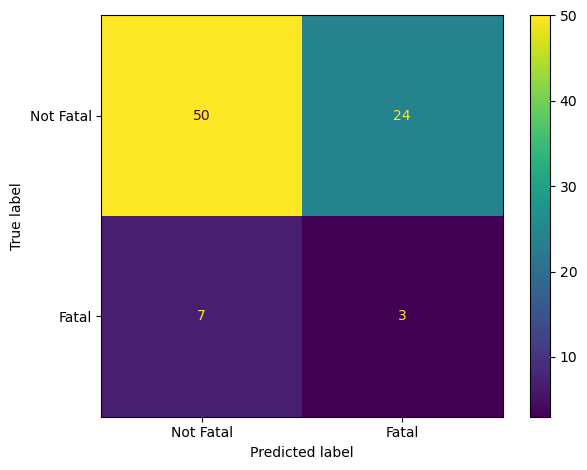

In [10]:
labels = ['Not Fatal', 'Fatal']

cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
cm_display.plot()  # Optional: add color for better visualization
#plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

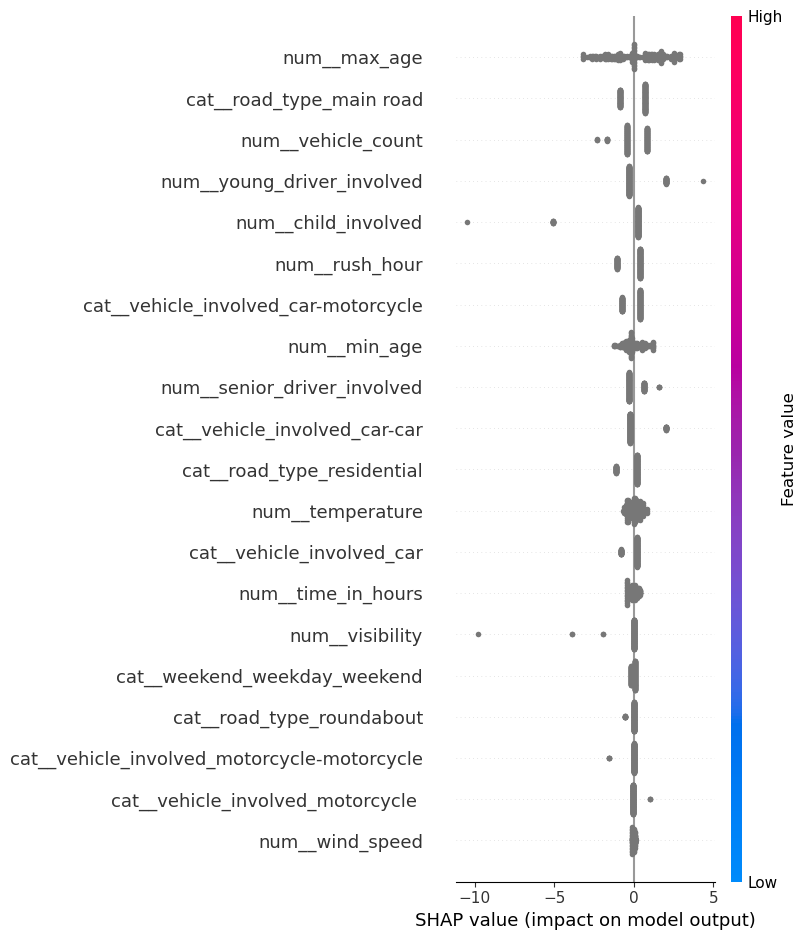

In [ ]:
log_reg = model.named_steps["logreg"]
preprocessor = model.named_steps["preprocess"]
X_transformed = preprocessor.transform(X_train)

explainer = shap.LinearExplainer(
    log_reg,
    X_transformed,
    feature_names=feature_names
)

shap_values = explainer(X_transformed)

shap.summary_plot(shap_values, feature_names=feature_names)

In [39]:
#Q3 Do senior drivers (>60) and certain locations show higher risk at certain road types ?
features = [
    "road_type",
    "senior_driver_involved",
]

X = df[features]
y = df["fatal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

categorical = ["road_type"]
numeric = ["senior_driver_involved"]
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
        ]), categorical),

        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]), numeric)
    ]
)

log_model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    class_weight="balanced"
)

model = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)), #used to balacnce samples when data is imbalanced
    ("logreg", log_model)
])



model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

coef = model.named_steps["logreg"].coef_[0]
feature_names = model.named_steps["preprocess"].get_feature_names_out()

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
}).sort_values("Coefficient", ascending=False)

#vehicle_factors = coef_df[coef_df["Feature"].str.startswith("cat__vehicle_involved")]
#print(vehicle_factors)

              precision    recall  f1-score   support

           0       0.89      0.54      0.67        74
           1       0.13      0.50      0.20        10

    accuracy                           0.54        84
   macro avg       0.51      0.52      0.44        84
weighted avg       0.80      0.54      0.62        84

[[40 34]
 [ 5  5]]


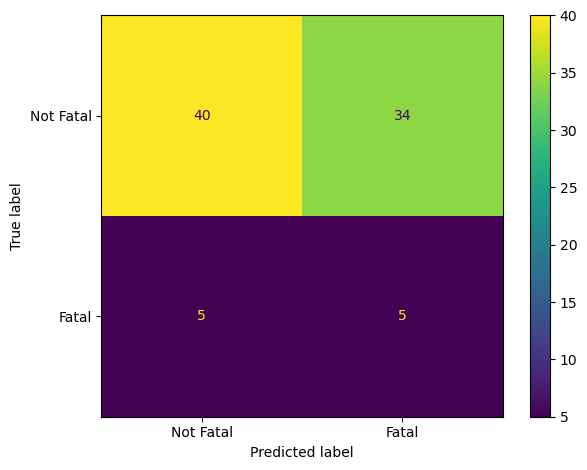

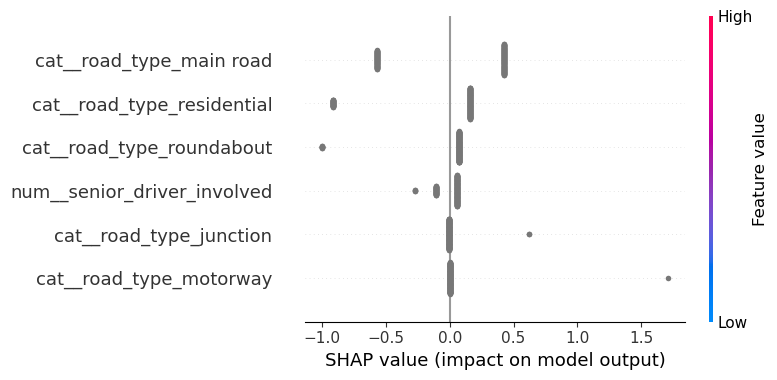

                       feature  odds_ratio
2      cat__road_type_motorway    5.511515
0      cat__road_type_junction    1.879097
5  num__senior_driver_involved    0.922694
1     cat__road_type_main road    0.369271
4    cat__road_type_roundabout    0.341948
3   cat__road_type_residential    0.340195
              precision    recall  f1-score   support

   Not Fatal       0.89      0.54      0.67        74
       Fatal       0.13      0.50      0.20        10

    accuracy                           0.54        84
   macro avg       0.51      0.52      0.44        84
weighted avg       0.80      0.54      0.62        84

ROC AUC: 0.47702702702702704


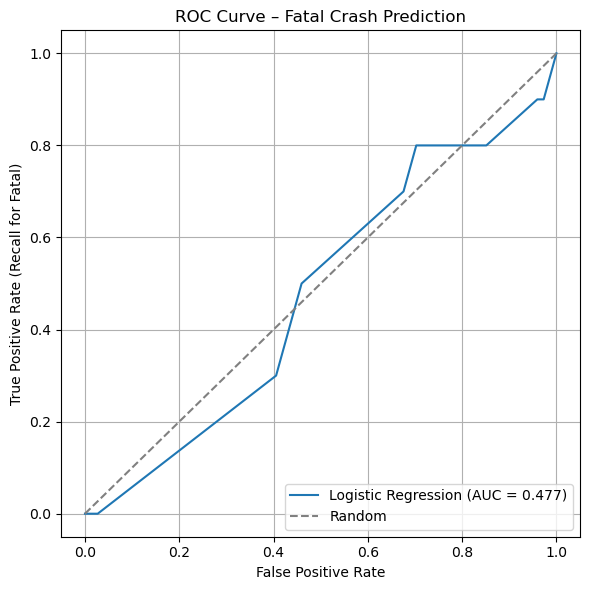

In [ ]:
labels = ['Not Fatal', 'Fatal']
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
cm_display.plot()
plt.tight_layout()
plt.show()


log_reg = model.named_steps["logreg"]
preprocessor = model.named_steps["preprocess"]
X_transformed = preprocessor.transform(X_train)

explainer = shap.LinearExplainer(
    log_reg,
    X_transformed,
    feature_names=feature_names
)

shap_values = explainer(X_transformed)
shap.summary_plot(shap_values, feature_names=feature_names)


#The OR represents the odds that an outcome will occur given a particular exposure, compared to the odds of the outcome occurring in the absence of that exposure. 
#Measure of association between an exposure and an outcome.
coef = log_reg.coef_[0]
odds_ratios = np.exp(coef)

or_table = pd.DataFrame({
    "feature": feature_names,
    "odds_ratio": odds_ratios
}).sort_values(by="odds_ratio", ascending=False)

print(or_table)


print(classification_report(y_test, y_pred, target_names=labels))
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("ROC AUC:", roc_auc)

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall for Fatal)")
plt.title("ROC Curve – Fatal Crash Prediction")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#Are certain times of day, days of the week, or rush-hour periods associated with a higher likelihood of accidents?”
# Are certain times of day, days of the week, or rush-hour periods associated with a higher likelihood of accidents.
features = [
    "vehicle_involved",
    "vehicle_count",
    "road_type",
    "min_age",
    "max_age",
    "young_driver_involved",
    "adult_driver_involved",
    "senior_driver_involved",
    "child_involved",
    "visibility",
    "wind_speed",
    "temperature",
    "time_in_hours",
    "rush_hour",
    "weekend_weekday"
]

X = df[features]
y = df["fatal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

categorical = ["vehicle_involved", "road_type", "weekend_weekday"]
numeric = [c for c in features if c not in categorical]
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
        ]), categorical),

        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]), numeric)
    ]
)

log_model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    class_weight="balanced"
)

model = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)), #used to balacnce samples when data is imbalanced
    ("logreg", log_model)
])



model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

coef = model.named_steps["logreg"].coef_[0]
feature_names = model.named_steps["preprocess"].get_feature_names_out()

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
}).sort_values("Coefficient", ascending=False)


              precision    recall  f1-score   support

           0       0.88      0.68      0.76        74
           1       0.11      0.30      0.16        10

    accuracy                           0.63        84
   macro avg       0.49      0.49      0.46        84
weighted avg       0.79      0.63      0.69        84

[[50 24]
 [ 7  3]]


c:\Users\nicho\miniconda3\envs\testEnv1\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
coef = log_reg.coef_[0]
p = log_reg.predict_proba(X_transformed)[:,1]
V = np.diag(p * (1 - p))
cov_matrix = np.linalg.inv(X_transformed.T @ V @ X_transformed)
se = np.sqrt(np.diag(cov_matrix))

ci_lower = np.exp(coef - 1.96 * se)
ci_upper = np.exp(coef + 1.96 * se)

odds_ratios = np.exp(coef)
or_table = pd.DataFrame({
    "feature": feature_names,
    "odds_ratio": odds_ratios,
    "ci_lower": ci_lower,
    "ci_upper": ci_upper
})

or_table = or_table.sort_values(by="odds_ratio", ascending=False).reset_index(drop=True)
print(or_table)

                                              feature  odds_ratio  \
0                       cat__vehicle_involved_car-car    9.352110   
1               cat__vehicle_involved_car-car-bicycle    4.425403   
2                       cat__vehicle_involved_van-bus    3.589155   
3                   cat__vehicle_involved_motorcycle     2.940032   
4                          num__young_driver_involved    2.510247   
5                                     num__visibility    2.273520   
6                             cat__road_type_motorway    2.262041   
7                     cat__vehicle_involved_car-truck    1.945369   
8                cat__vehicle_involved_bus-pedestrian    1.832036   
9                                        num__min_age    1.723741   
10                        num__senior_driver_involved    1.578286   
11                            cat__road_type_junction    1.495025   
12                                   num__temperature    1.418808   
13                                